In [72]:
import lasio
import os
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [73]:
las3 = lasio.read("WELL_3.las")
dff= las3.df()
dff

,GAMMA,PERM,POROSITY,RESISTIVITY,LITH
DEPT,,,,,
1808.8947,NaN,NaN,NaN,NaN,NaN
1809.3947,84.426910,0.000819,0.001897,0.652335,2.0
1809.8947,72.081619,0.001172,0.001951,1.256779,2.0
1810.3947,73.515076,0.001056,0.001919,1.058033,2.0
1810.8947,78.625954,0.000814,0.001899,0.644028,2.0
...,...,...,...,...,...
2082.3947,43.805794,0.002838,0.001201,21.431606,1.0
2082.8947,43.354637,0.002697,NaN,NaN,NaN
2083.3947,NaN,NaN,NaN,NaN,NaN


In [74]:
def load_las(path, well_name):
    las = lasio.read(path)
    df = las.df().reset_index()   # depth becomes a column
    df["WELL"] = well_name        # add well identifier
    return df


In [75]:
df1 = load_las("WELL_1.las", "1")
df2 = load_las("WELL_2.las", "2")
df3 = load_las("WELL_3.las", "3")
df4 = load_las("WELL_4.las", "4")


In [76]:
las_test = lasio.read("test1.las")
df_test = las_test.df().reset_index()
df_test

,DEPT,GAMMA,POROSITY,RESISTIVITY,LITH
0,1902.2873,65.39847,0.00213,0.52259,2.0
1,1902.7873,63.72424,0.00216,0.49934,2.0
2,1903.2873,60.51658,0.00222,0.75043,3.0
3,1903.7873,56.17398,0.00232,1.28660,3.0
4,1904.2873,52.38428,0.00243,1.59704,3.0
...,...,...,...,...,...
5743,2334.1009,80.76042,0.00118,6.02426,1.0
5744,2334.6009,75.82806,0.00123,24.19512,1.0
5745,2335.1009,70.92965,0.00122,55.35276,1.0
5746,2335.6009,66.16563,0.00105,125.44728,2.0


In [77]:
df2.shape

(701, 7)

In [78]:
df3.shape

(552, 7)

In [79]:
df4.shape

(2524, 7)

In [80]:
df_train = pd.concat([df1, df2, df3, df4], ignore_index=True)


In [81]:
df_train.shape

(5612, 7)

In [82]:
df_test.shape

(5748, 5)

In [83]:
df_test.isna().sum()

DEPT           0
GAMMA          0
POROSITY       0
RESISTIVITY    4
LITH           0
dtype: int64

In [84]:
df_test['RESISTIVITY'] = df_test['RESISTIVITY'].fillna(df_test['RESISTIVITY'].mean())


In [85]:
df_test.isna().sum()

DEPT           0
GAMMA          0
POROSITY       0
RESISTIVITY    0
LITH           0
dtype: int64

In [86]:
df_train

,DEPT,GAMMA,PERM,POROSITY,RESISTIVITY,LITH,WELL
0,1499.8790,NaN,NaN,NaN,NaN,NaN,1
1,1500.1290,NaN,NaN,NaN,NaN,NaN,1
2,1500.6290,NaN,NaN,NaN,NaN,NaN,1
3,1501.1290,NaN,NaN,0.002706,NaN,NaN,1
4,1501.6290,78.869453,0.001246,0.002674,0.709644,3.0,1
...,...,...,...,...,...,...,...
5607,2756.1063,NaN,NaN,NaN,NaN,NaN,4
5608,2756.6063,NaN,NaN,NaN,NaN,NaN,4
5609,2757.1063,NaN,NaN,NaN,NaN,NaN,4
5610,2757.6063,NaN,NaN,NaN,NaN,NaN,4


In [87]:
import numpy as np
df_train['log_RES'] = np.log(df_train['RESISTIVITY'] + 1)  # +1 to avoid log(0)
df_train['LOG_PERM'] = np.log1p(df_train['PERM'])


In [88]:
# df_train['log_RES'] = np.log(df_train['RESISTIVITY'] + 1) 
GR_min = df_train['GAMMA'].quantile(0.05)
GR_max = df_train['GAMMA'].quantile(0.95)

df_train['VSH'] = (df_train['GAMMA'] - GR_min) / (GR_max - GR_min)
df_train['VSH'] = df_train['VSH'].clip(0, 1)
df_train.head()

,DEPT,GAMMA,PERM,POROSITY,RESISTIVITY,LITH,WELL,log_RES,LOG_PERM,VSH
0,1499.879,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN
1,1500.129,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN
2,1500.629,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN
3,1501.129,NaN,NaN,0.002706,NaN,NaN,1,NaN,NaN,NaN
4,1501.629,78.869453,0.001246,0.002674,0.709644,3.0,1,0.536285,0.001245,0.296003


In [89]:
df_test['log_RES'] = np.log(df_test['RESISTIVITY'] + 1)
df_test['VSH'] = (df_test['GAMMA'] - GR_min) / (GR_max - GR_min)


In [90]:
df_train['WELL'].value_counts()

WELL
4    2524
1    1835
2     701
3     552
Name: count, dtype: int64

In [91]:
df_train['LITH'].value_counts()

LITH
2.0    2777
3.0    1376
1.0    1335
0.0      98
Name: count, dtype: int64

In [92]:
df_train = df_train.dropna()
# df_test = df_test.dropna(subset=['GAMMA']).reset_index(drop=True)


df_train.reset_index(drop=True, inplace=True)
# df_test.reset_index(drop=True, inplace=True)
df_train.shape
# df_test.shape

(5586, 10)

In [93]:
df_train

,DEPT,GAMMA,PERM,POROSITY,RESISTIVITY,LITH,WELL,log_RES,LOG_PERM,VSH
0,1501.6290,78.869453,0.001246,0.002674,0.709644,3.0,1,0.536285,0.001245,0.296003
1,1502.1290,78.008301,0.001253,0.002561,0.790188,3.0,1,0.582320,0.001253,0.281170
2,1502.6290,75.581558,0.001171,0.002421,0.780511,3.0,1,0.576900,0.001171,0.239371
3,1503.1290,73.238037,0.001096,0.002386,0.706579,3.0,1,0.534491,0.001096,0.199005
4,1503.6290,71.504173,0.001060,0.002384,0.661791,3.0,1,0.507896,0.001060,0.169140
...,...,...,...,...,...,...,...,...,...,...
5581,2753.6063,100.353752,0.001659,0.000911,13.438418,1.0,4,2.669893,0.001657,0.666058
5582,2754.1063,102.964821,0.002032,0.000976,17.351480,1.0,4,2.909710,0.002030,0.711033
5583,2754.6063,91.596367,0.002125,0.001111,14.252602,1.0,4,2.724750,0.002123,0.515217
5584,2755.1063,82.100845,0.002020,0.001143,12.103153,1.0,4,2.572853,0.002018,0.351662


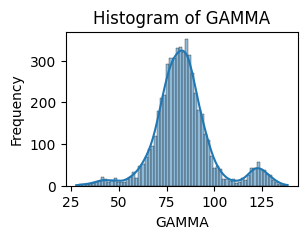

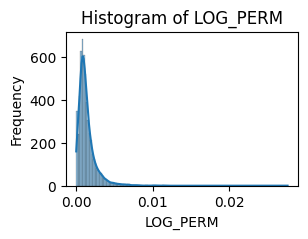

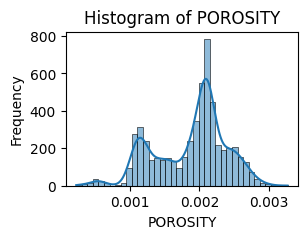

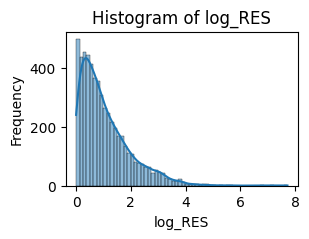

In [94]:
import seaborn as sns
logs = ['GAMMA', 'LOG_PERM', 'POROSITY', 'log_RES']

for col in logs:
    plt.figure(figsize=(3,2))
    sns.histplot(df_train[col], kde=True)
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()


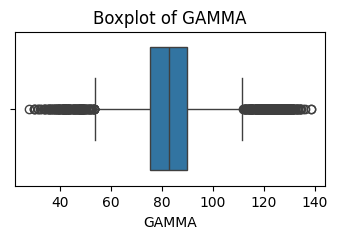

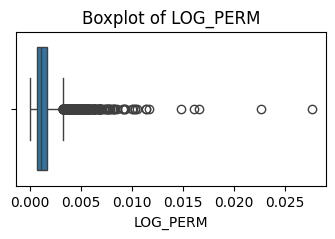

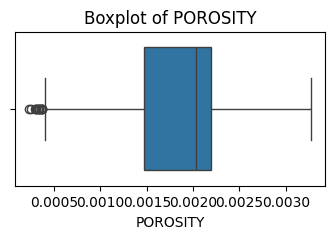

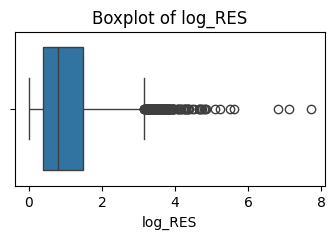

In [95]:
for col in logs:
    plt.figure(figsize=(4,2))
    sns.boxplot(x=df_train[col])
    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)
    plt.show()


In [96]:
# sns.distplot(df_train['GAMMA'])

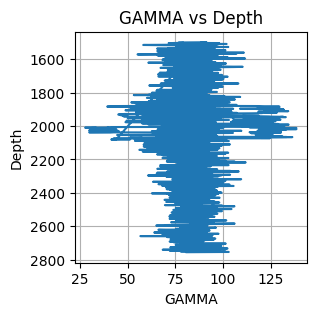

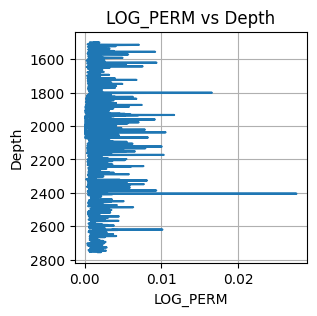

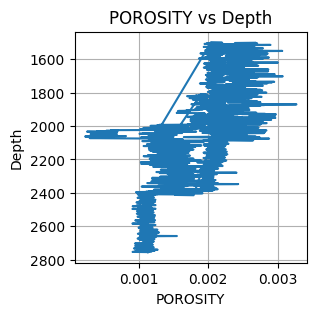

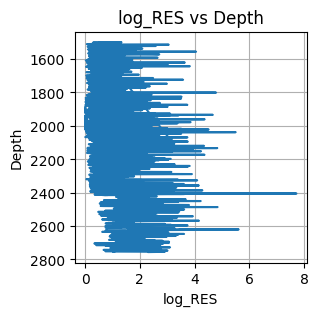

In [97]:
for col in logs:
    plt.figure(figsize=(3,3))
    plt.plot(df_train[col], df_train['DEPT'])
    plt.gca().invert_yaxis()   # Depth increases downward
    plt.xlabel(col)
    plt.ylabel('Depth')
    plt.title(f'{col} vs Depth')
    plt.grid(True)
    plt.show()


In [98]:
df_train['delta_gr'] = df_train['GAMMA'].diff().abs()
df_clean = df_train[df_train['delta_gr'] < df_train['delta_gr'].quantile(0.99)]


C:\Users\muska\AppData\Local\Temp\ipykernel_28172\2523706014.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train['delta_gr'] = df_train['GAMMA'].diff().abs()


In [99]:
df_clean = df_clean.drop(columns=['delta_gr'])

In [100]:
def remove_outliers_iqr(df, columns, factor=1.5):
    df_clean1 = df.copy()
    for col in columns:
        if df_clean1[col].dtype != 'object':
            Q1 = df_clean1[col].quantile(0.25)
            Q3 = df_clean1[col].quantile(0.75)
            IQR = Q3 - Q1
            lower = Q1 - factor * IQR
            upper = Q3 + factor * IQR
            df_clean1 = df_clean1[(df_clean1[col] >= lower) & (df_clean1[col] <= upper) | df_clean1[col].isna()]
    return df_clean1
columns = ['GAMMA', 'LOG_PERM', 'POROSITY', 'RESISTIVITY', 'log_RES', 'VSH']
df_clean1 = remove_outliers_iqr(df_clean, columns)


In [101]:
df_clean2 = df_clean1.copy()

# Remove impossible values based on domain knowledge
df_clean2 = df_clean2[
    (df_clean2['GAMMA'] >= 0) & (df_clean2['GAMMA'] <= 350) &
    (df_clean2['RESISTIVITY'] > 0) & (df_clean2['RESISTIVITY'] <= 5000) &
    (df_clean2['POROSITY'] >= 0) & (df_clean2['POROSITY'] <= 1) 
    # (df_clean['DENSITY'] >= 1) & (df_clean['DENSITY'] <= 3.5)
]


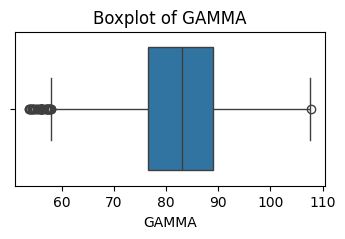

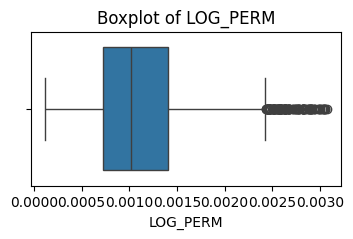

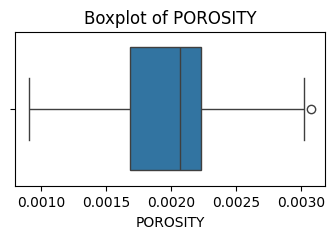

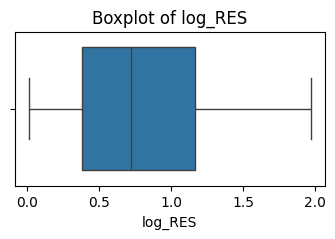

In [102]:
for col in logs:
    plt.figure(figsize=(4,2))
    sns.boxplot(x=df_clean2[col])
    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)
    plt.show()

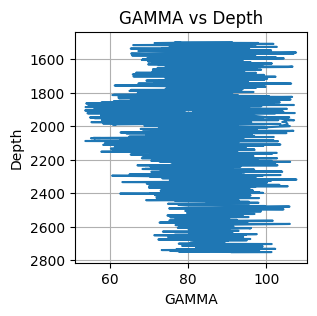

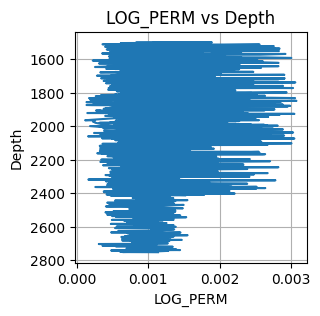

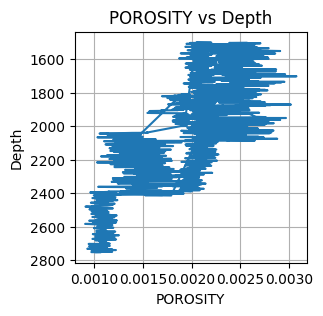

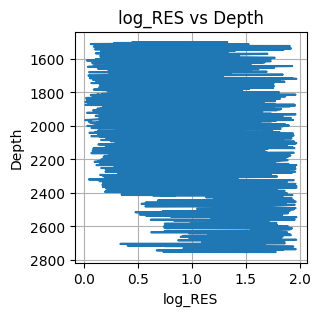

In [103]:
for col in logs:
    plt.figure(figsize=(3,3))
    plt.plot(df_clean2[col], df_clean2['DEPT'])
    plt.gca().invert_yaxis()   # Depth increases downward
    plt.xlabel(col)
    plt.ylabel('Depth')
    plt.title(f'{col} vs Depth')
    plt.grid(True)
    plt.show()


In [104]:
# for col in logs:
#     plt.figure(figsize=(6,3))
#     sns.boxplot(x=df_train[col])
#     plt.title(f'Boxplot of {col}')
#     plt.xlabel(col)
#     plt.show()

Z SCORE

In [105]:
# from scipy import stats
# import numpy as np



# z = np.abs(stats.zscore(df[logs]))

# df_clean1 = df[(z < 3).all(axis=1)]


In [106]:
# for col in logs:
#     plt.figure(figsize=(6,3))
#     sns.boxplot(x=df_clean1[col])
#     plt.title(f'Boxplot of {col}')
#     plt.xlabel(col)
#     plt.show()

In [107]:
df_train[df_train.select_dtypes(include=['number']) < 0].any()
#for negative values

DEPT           False
GAMMA          False
PERM           False
POROSITY       False
RESISTIVITY    False
LITH           False
WELL           False
log_RES        False
LOG_PERM       False
VSH            False
delta_gr       False
dtype: bool

In [108]:
df_train.isna().sum()
# df_test.isna().sum()

DEPT           0
GAMMA          0
PERM           0
POROSITY       0
RESISTIVITY    0
LITH           0
WELL           0
log_RES        0
LOG_PERM       0
VSH            0
delta_gr       1
dtype: int64

In [109]:
from xgboost import XGBRegressor
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error,  mean_absolute_error, r2_score

numeric_cols = ['GAMMA', 'RESISTIVITY', 'POROSITY', 'log_RES', 'VSH']  
categorical_cols = ['LITH'] 

X_train_f = df_train[numeric_cols + categorical_cols]
y_train_f = df_train['LOG_PERM']
groups = df_train['WELL']

X_test_f = df_test[numeric_cols + categorical_cols]
# y_test_f = df_test['PERM']


In [110]:
# from sklearn.model_selection import train_test_split
# X_train, X_test, y_train, y_test= train_test_split(X_train_f, y_train_f, test_size = 0.3, random_state=42)

In [111]:
preprocessor = ColumnTransformer(transformers=[
    ('num', 'passthrough', numeric_cols),
    ('cat', OneHotEncoder(handle_unknown="ignore"), categorical_cols)
])

# model = RandomForestRegressor(random_state=42)
# model = XGBRegressor()
model = XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)
# model = XGBRegressor(
#     n_estimators=300,
#     learning_rate=0.03,
#     max_depth=3,
#     subsample=0.7,
#     colsample_bytree=0.6,
#     reg_alpha=0.5,
#     reg_lambda=5.0,
#     min_child_weight=5,
#     random_state=42
# )

# Combine preprocessing + model
pipeline = Pipeline(steps=[
    ('prep', preprocessor),
    ('model', model)
])
pipeline

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['GAMMA', 'RESISTIVITY',
                                                   'POROSITY', 'log_RES',
                                                   'VSH']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['LITH'])])),
                ('model',
                 XGBRegressor(base_score=None, booster=None, callbacks=None,
                              colsample_bylevel=None, colsample_bynode=None,
                              colsample_bytree=None, device=None,
                              early_stopping_ro...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=None,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=None, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=None, n_jobs=-1,
                              num_parallel_tree=None, ...))])

In [112]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

param_dist = {
    'model__n_estimators': randint(200, 800),
    'model__learning_rate': uniform(0.01, 0.15),
    'model__max_depth': randint(3, 10),
    'model__subsample': uniform(0.6, 0.4),
    'model__colsample_bytree': uniform(0.4, 0.6),
    'model__reg_alpha': uniform(0.0, 1.0),
    'model__reg_lambda': uniform(1.0, 5.0)
}


logo = LeaveOneGroupOut()

# random_search = RandomizedSearchCV(
#     estimator=pipeline,
#     param_distributions=param_dist,
#     n_iter=40,   # 30–50 is ideal
#     scoring='neg_mean_squared_error',
#     cv=logo,
#     verbose=3,
#     n_jobs=-1,
#     random_state=42
# )

# random_search.fit(X_train_f, y_train_f, groups=groups)

# print("Best parameters:")
# print(random_search.best_params_)
# best_pipeline = random_search.best_estimator_

In [113]:
# from sklearn.model_selection import RandomizedSearchCV
# from scipy.stats import randint, uniform
# param_grid = {
#     'model__n_estimators': randint(200, 400),
#     'model__max_depth': [10, 20, 40, None],
#     'model__min_samples_split': randint(2, 20),
#     'model__min_samples_leaf': randint(1, 10),
#     'model__max_features': ['sqrt', 0.3, 0.5, None],
#     'model__bootstrap': [True, False]
# }

# logo = LeaveOneGroupOut()

# grid = RandomizedSearchCV(
#     estimator=pipeline,
#     param_distributions=param_grid,
#     n_iter=40,                 # try 40 random combinations
#     scoring='neg_mean_squared_error',
#     cv=logo,                   # use LOWO
#     verbose=3,
#     n_jobs=-1,
#     random_state=42
# )

# grid.fit(X_train_f, y_train_f, groups=groups)

# print("Best Params:", grid.best_params_)
# best_pipeline = grid.best_estimator_


In [114]:
logo = LeaveOneGroupOut()

rmse_scores = []
mae_scores = []
r2_scores = []

all_y_test = []
all_y_pred = []

for train_idx, test_idx in logo.split(X_train_f, y_train_f, groups):
    well_name = df_train.iloc[test_idx]['WELL'].unique()[0]
   

    X_train, X_test = X_train_f.iloc[train_idx], X_train_f.iloc[test_idx]
    y_train, y_test = y_train_f.iloc[train_idx], y_train_f.iloc[test_idx]

    # Fit only on training wells
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    y_test_real = np.expm1(y_test.values)
    y_pred_real = np.expm1(y_pred)

    all_y_test.extend(y_test_real)
    all_y_pred.extend(y_pred_real)

    #performance metrics

    # rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test_real, y_pred_real)
    # r2   = r2_score(y_test, y_pred)
    # rmse_scores.append(rmse)
    mae_scores.append(mae)
    # r2_scores.append(r2)

# print("RMSE for each fold:", rmse_scores)
# print("RMSE for each fold:", [f"{x:.4f}" for x in rmse_scores])

print("MAE for each fold:", [f"{x:.4f}" for x in mae_scores])
# print("R2 for each fold:", [f"{x:.4f}" for x in r2_scores])

# print(f"RMSE: {np.mean(rmse_scores):.6f} ± {np.std(rmse_scores):.6f}")

print(f"MAE: {np.mean(mae_scores):.6f} ± {np.std(mae_scores):.6f}")
# print(f"R2: {np.mean(r2_scores):.6f} ± {np.std(r2_scores):.6f}")

# print("Std RMSE:", np.std(rmse_scores))
# def regression_metrics(y_true, y_pred):
#     rmse = np.sqrt(mean_squared_error(y_true, y_pred))
#     mae  = mean_absolute_error(y_true, y_pred)
#     r2   = r2_score(y_true, y_pred)
#     return {'RMSE': rmse, 'MAE': mae, 'R2': r2}

# metrics = regression_metrics(y_test, y_pred)
# metrics

MAE for each fold: ['0.0001', '0.0001', '0.0001', '0.0001']
MAE: 0.000104 ± 0.000021


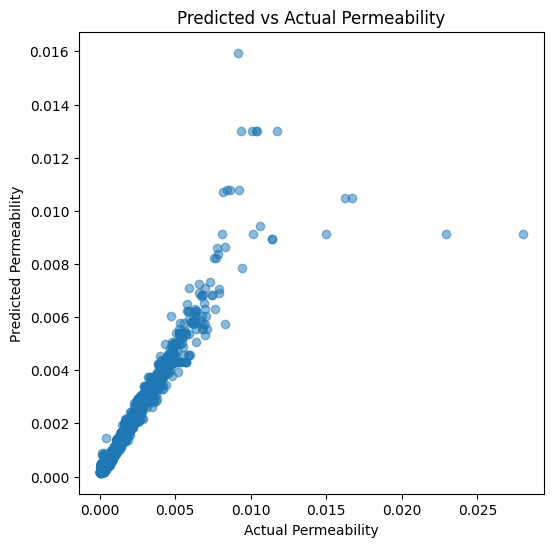

In [115]:
plt.figure(figsize=(6, 6))
plt.scatter(all_y_test, all_y_pred, alpha=0.5)

plt.xlabel("Actual Permeability")
plt.ylabel("Predicted Permeability")
plt.title("Predicted vs Actual Permeability")
plt.show()

In [116]:
#training final model
pipeline.fit(X_train_f, y_train_f)
y_pred_test = pipeline.predict(X_test_f)

In [117]:
perm_pred = np.expm1(y_pred_test)
perm_pred

array([0.00079997, 0.00083875, 0.0010535 , ..., 0.00457697, 0.00640721,
       0.00750345], shape=(5748,), dtype=float32)

In [118]:
submission = pd.DataFrame({
    'id': df_test['DEPT'],            
    'Permeability': perm_pred
})
submission.to_csv('submission2.csv', index=False)

In [119]:
# After training pipeline
preprocessor = pipeline.named_steps['prep']

# Numeric feature names (unchanged)
num_features = preprocessor.named_transformers_['num'].get_feature_names_out()

# Categorical one-hot feature names
cat_features = preprocessor.named_transformers_['cat'].get_feature_names_out()

# Combined feature list
feature_names = list(num_features) + list(cat_features)


In [120]:
model = pipeline.named_steps['model']

importances = model.feature_importances_

fi_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

print(fi_df)


       feature  importance
1  RESISTIVITY    0.374844
6     LITH_1.0    0.361853
8     LITH_3.0    0.159703
2     POROSITY    0.049202
0        GAMMA    0.024027
5     LITH_0.0    0.017298
4          VSH    0.013073
3      log_RES    0.000000
7     LITH_2.0    0.000000


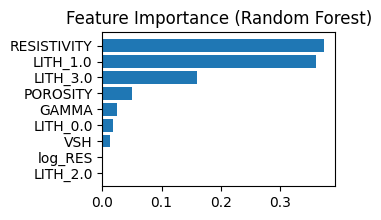

In [121]:
plt.figure(figsize=(3,2))
plt.barh(fi_df['feature'], fi_df['importance'])
plt.gca().invert_yaxis()
plt.title("Feature Importance (Random Forest)")
plt.show()

In [122]:
# from sklearn.inspection import PartialDependenceDisplay

# PartialDependenceDisplay.from_estimator(
#     pipeline,
#     features=['GAMMA', 'RESISTIVITY', 'POROSITY', 'VSH', 'log_RES' ],
#     kind='average',
    
# )
# plt.show()


normal XGBregressor = RMSE for each fold: ['0.0003', '0.0001', '0.0003', '0.0005']
MAE for each fold: ['0.0001', '0.0001', '0.0001', '0.0001']
R2 for each fold: ['0.9373', '0.9895', '0.9233', '0.8550']
RMSE: 0.000325 ± 0.000137
MAE: 0.000104 ± 0.000020
R2: 0.926288 ± 0.047978

tuned XGB: RMSE for each fold: ['0.0004', '0.0002', '0.0003', '0.0006']
MAE for each fold: ['0.0002', '0.0001', '0.0001', '0.0002']
R2 for each fold: ['0.9131', '0.9725', '0.9512', '0.7875']
RMSE: 0.000369 ± 0.000159
MAE: 0.000169 ± 0.000025
R2: 0.906076 ± 0.071716

In [1]:
print("Muskan")

Muskan
